In [19]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import cv2
import seaborn as sns


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report, confusion_matrix

In [10]:
data_dir = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

In [11]:
import os

for folder in os.listdir(data_dir):
    print(folder)

no
yes


In [12]:
img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)
print(train_data.class_indices)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
{'no': 0, 'yes': 1}


In [13]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

I0000 00:00:1773773630.568587      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773773630.575149      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1773773672.536588     183 service.cc:152] XLA service 0x7f29f812e620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773773672.536640     183 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773773672.536647     183 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773773676.897588     183 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-17 18:54:46.778159: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 18:54:46.918994: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 18:54:47.056016: E external/local_xl

1/7 ━━━━━━━━━━━━━━━━━━━━ 6:08 61s/step - accuracy: 0.6562 - loss: 0.6360

2026-03-17 18:55:20.564047: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 18:55:20.701293: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7213 - loss: 0.6598

2026-03-17 18:55:53.905896: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 18:55:54.042977: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


7/7 ━━━━━━━━━━━━━━━━━━━━ 109s 8s/step - accuracy: 0.7247 - loss: 0.6525 - val_accuracy: 0.7800 - val_loss: 0.4206
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.8811 - loss: 0.2858 - val_accuracy: 0.6800 - val_loss: 1.6605
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.9811 - loss: 0.0738 - val_accuracy: 0.6200 - val_loss: 2.9097
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.9786 - loss: 0.0527 - val_accuracy: 0.5600 - val_loss: 4.9227
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.9821 - loss: 0.0722 - val_accuracy: 0.6600 - val_loss: 5.2064


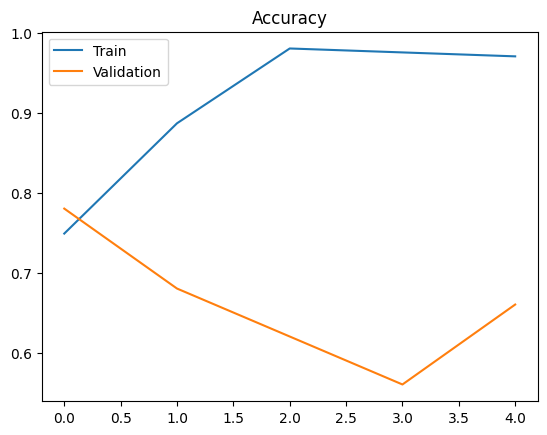

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

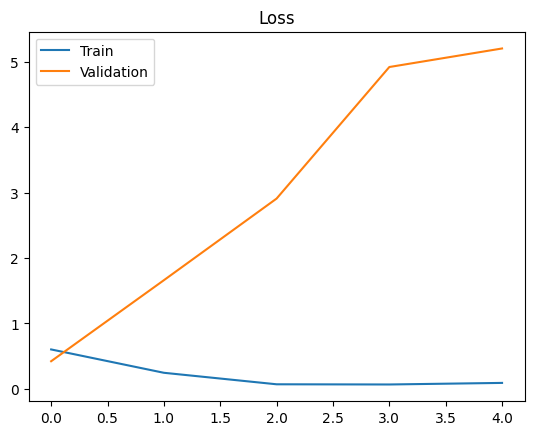

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['Train', 'Validation'])
plt.show()

In [17]:
y_pred = model.predict(val_data)
y_pred_classes = (y_pred > 0.5).astype("int32").flatten()

y_true = val_data.classes

print(classification_report(y_true, y_pred_classes))

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step
              precision    recall  f1-score   support

           0       0.39      0.74      0.51        19
           1       0.64      0.29      0.40        31

    accuracy                           0.46        50
   macro avg       0.52      0.51      0.45        50
weighted avg       0.55      0.46      0.44        50



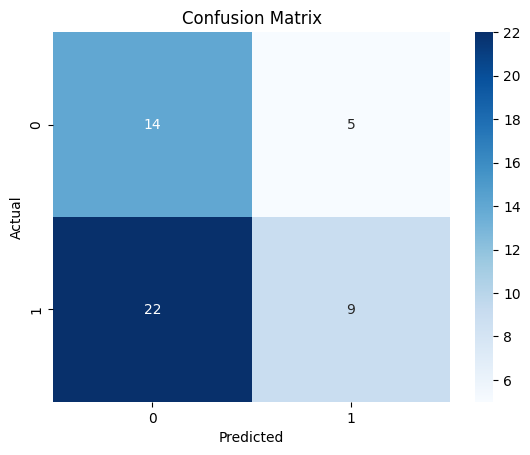

In [20]:
cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
def get_gradcam(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [22]:
# get one image
img_path = train_data.filepaths[0]

img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

img_array = np.expand_dims(img/255.0, axis=0)

# IMPORTANT: last conv layer name for MobileNetV2
last_conv_layer = "Conv_1"

heatmap = get_gradcam(model, img_array, last_conv_layer)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


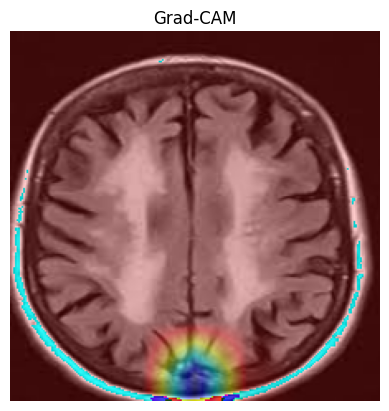

In [23]:
heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap_color * 0.4 + img

plt.imshow(superimposed_img.astype('uint8'))
plt.axis('off')
plt.title("Grad-CAM")
plt.show()